# Setup and Installation
Install and import all required libraries including PyTorch, Transformers, Sentence Transformers, NLTK, pandas, NumPy, and scikit-learn. Set up environment configurations and global parameters.

In [ ]:
# Install required libraries
!pip install torch transformers sentence-transformers nltk pandas numpy scikit-learn graphviz

# Deep learning libraries
import torch
from transformers import BertModel, BertTokenizer
from sentence_transformers import SentenceTransformer

# NLP libraries
import nltk

# Data processing libraries
import pandas as pd
import numpy as np

# Machine learning libraries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score

# Download necessary NLTK datasets and models
nltk.download('treebank')      # Penn Treebank sample corpus
nltk.download('punkt')         # Pre-trained tokenizer
nltk.download('punkt_tab')     # Tab-delimited version of punkt
nltk.download('averaged_perceptron_tagger')  # ML-based POS tagger model
from nltk.corpus import treebank

import os

#-------------------------------------------------------------------------------
# Set up the appropriate device (CUDA, MPS, or CPU)
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

# Define model names
BERT_MODEL_NAME = 'bert-base-uncased'  # Standard BERT model (not case-sensitive)
SENTENCE_TRANSFORMER_MODEL_NAME = 'all-MiniLM-L6-v2'  # Lightweight sentence embedding model

# Load transformer models
print(f"Loading {BERT_MODEL_NAME}...")
bert_model = BertModel.from_pretrained(BERT_MODEL_NAME).to(device)
bert_tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)

print(f"Loading {SENTENCE_TRANSFORMER_MODEL_NAME}...")
sentence_transformer_model = SentenceTransformer(SENTENCE_TRANSFORMER_MODEL_NAME).to(device)

print("loaded successfully!")

/Users/larsheijnen/VSCode_S2/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package treebank to
[nltk_data]     /Users/larsheijnen/nltk_data...
[nltk_data]   Package treebank is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/larsheijnen/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/larsheijnen/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/larsheijnen/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Using device: mps
Loading bert-base-uncased...
Loading all-MiniLM-L6-v2...
loaded successfully!


# Pipeline Architecture
Define the core pipeline architecture with modular components. Create base classes that establish interfaces for each module. Visualize the pipeline structure using diagrams to illustrate data flow.

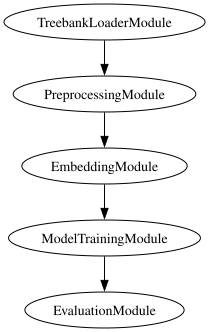

In [ ]:
# Define the core pipeline architecture with modular components

# Base class for pipeline modules
class PipelineModule:
    def __init__(self, name):
        self.name = name

    def process(self, data):
        raise NotImplementedError("Each module must implement the process method.")

# Treebank data loading module
class TreebankLoaderModule(PipelineModule):
    def __init__(self, name):
        super().__init__(name)
    
    def process(self, data=None):
        # Load directly from NLTK - no file path needed
        from nltk.corpus import treebank
        sentences = treebank.tagged_sents()
        
        data = []
        for sent in sentences:
            words, tags = zip(*sent)
            sentence = ' '.join(words)
            for word, tag in sent:
                data.append({'sentence': sentence, 'word': word, 'tag': tag})
        
        return pd.DataFrame(data)

# Preprocessing module
class PreprocessingModule(PipelineModule):
    def __init__(self, name):
        super().__init__(name)

    def process(self, data):
        # Tokenize sentences using NLTK
        data['tokens'] = data['sentence'].apply(nltk.word_tokenize)
        return data

# Embedding creation module
class EmbeddingModule(PipelineModule):
    def __init__(self, name, model, tokenizer):
        super().__init__(name)
        self.model = model
        self.tokenizer = tokenizer

    def process(self, data):
        # Generate embeddings using BERT
        def get_embeddings(sentence):
            inputs = self.tokenizer(sentence, return_tensors='pt', truncation=True, padding=True).to(device)
            outputs = self.model(**inputs)
            return outputs.last_hidden_state.mean(dim=1).squeeze().cpu().detach().numpy()

        data['embeddings'] = data['sentence'].apply(get_embeddings)
        return data

# Model training module
class ModelTrainingModule(PipelineModule):
    def __init__(self, name, model):
        super().__init__(name)
        self.model = model

    def process(self, data):
        # Train logistic regression model
        X = np.vstack(data['embeddings'].values)
        y = data['label']
        self.model.fit(X, y)
        return self.model

# Evaluation module
class EvaluationModule(PipelineModule):
    def __init__(self, name, model):
        super().__init__(name)
        self.model = model

    def process(self, data):
        # Evaluate model performance
        X = np.vstack(data['embeddings'].values)
        y = data['label']
        y_pred = self.model.predict(X)
        accuracy = accuracy_score(y, y_pred)
        precision = precision_score(y, y_pred, average='weighted')
        recall = recall_score(y, y_pred, average='weighted')
        f1 = f1_score(y, y_pred, average='weighted')
        return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Visualizing the pipeline structure using diagrams to illustrate data flow
from graphviz import Digraph

def visualize_pipeline():
    dot = Digraph(comment='Pipeline Architecture')
    dot.node('A', 'TreebankLoaderModule')
    dot.node('B', 'PreprocessingModule')
    dot.node('C', 'EmbeddingModule')
    dot.node('D', 'ModelTrainingModule')
    dot.node('E', 'EvaluationModule')

    dot.edges(['AB', 'BC', 'CD', 'DE'])
    return dot

# Example usage
# data_loader = DataLoaderModule('DataLoader', 'path/to/data.csv')
preprocessing = PreprocessingModule('Preprocessing')
embedding = EmbeddingModule('Embedding', bert_model, bert_tokenizer)
model_training = ModelTrainingModule('ModelTraining', LogisticRegression())
evaluation = EvaluationModule('Evaluation', model_training.model)

# Visualize the pipeline
visualize_pipeline()

# Data Loading Module
Implement flexible data loaders for different datasets (Treebank, custom datasets). Create abstract interfaces for consistent data loading patterns. Include examples using built-in datasets and custom data formats.

In [ ]:
# Data Loading Module

class TreebankLoaderModule(PipelineModule):
    def __init__(self, name):
        super().__init__(name)
    
    def process(self, data=None):
        # Load directly from NLTK - no file path needed
        from nltk.corpus import treebank
        sentences = treebank.tagged_sents()
        
        data = []
        for sent in sentences:
            words, tags = zip(*sent)
            sentence = ' '.join(words)
            for word, tag in sent:
                data.append({'sentence': sentence, 'word': word, 'tag': tag})
        
        return pd.DataFrame(data)

# Create module instance
treebank_module = TreebankLoaderModule("treebank_loader")

# Load data using the pipeline module
treebank_data = treebank_module.process()

# Display loaded data
print(treebank_data.head())

                                            sentence    word  tag
0  Pierre Vinken , 61 years old , will join the b...  Pierre  NNP
1  Pierre Vinken , 61 years old , will join the b...  Vinken  NNP
2  Pierre Vinken , 61 years old , will join the b...       ,    ,
3  Pierre Vinken , 61 years old , will join the b...      61   CD
4  Pierre Vinken , 61 years old , will join the b...   years  NNS


# Preprocessing Module
Develop text preprocessing utilities including tokenization, normalization, and filtering. Create pipeline-compatible transformer classes for text preprocessing. Implement feature extraction methods specific to linguistic properties.

In [ ]:
# Preprocessing Module

# Import necessary libraries for preprocessing
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.base import TransformerMixin

# Download NLTK stopwords
nltk.download('stopwords')

# Define text preprocessing utilities
class TextPreprocessor(TransformerMixin):
    def __init__(self, remove_stopwords=True, lowercase=True):
        self.remove_stopwords = remove_stopwords
        self.lowercase = lowercase
        self.stop_words = set(stopwords.words('english')) if remove_stopwords else None

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        return X.apply(self._preprocess_text)

    def _preprocess_text(self, text):
        tokens = word_tokenize(text)
        if self.lowercase:
            tokens = [token.lower() for token in tokens]

        if self.remove_stopwords:
            tokens = [token for token in tokens if token not in self.stop_words]
        return tokens

# pipeline-compatible transformer class for text preprocessing
class PreprocessingModule(PipelineModule):
    def __init__(self, name, remove_stopwords=True, lowercase=True):
        super().__init__(name)
        self.preprocessor = TextPreprocessor(remove_stopwords, lowercase)

    def process(self, data):
        # Apply text preprocessing
        data['processed_text'] = self.preprocessor.transform(data['sentence'])
        return data

# Example usage of the PreprocessingModule
preprocessing = PreprocessingModule('Preprocessing')
processed_data = preprocessing.process(treebank_data)

# Display processed data
print(processed_data.head())

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/larsheijnen/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


                                            sentence    word  tag  \
0  Pierre Vinken , 61 years old , will join the b...  Pierre  NNP   
1  Pierre Vinken , 61 years old , will join the b...  Vinken  NNP   
2  Pierre Vinken , 61 years old , will join the b...       ,    ,   
3  Pierre Vinken , 61 years old , will join the b...      61   CD   
4  Pierre Vinken , 61 years old , will join the b...   years  NNS   

                                      processed_text  
0  [pierre, vinken, ,, 61, years, old, ,, join, b...  
1  [pierre, vinken, ,, 61, years, old, ,, join, b...  
2  [pierre, vinken, ,, 61, years, old, ,, join, b...  
3  [pierre, vinken, ,, 61, years, old, ,, join, b...  
4  [pierre, vinken, ,, 61, years, old, ,, join, b...  


# Embedding Generation Module
Create wrappers for various LLMs (BERT, GPT, etc.). Implement layer-specific embedding extraction. Add caching mechanisms for efficiency. Include visualization tools for embedding analysis.

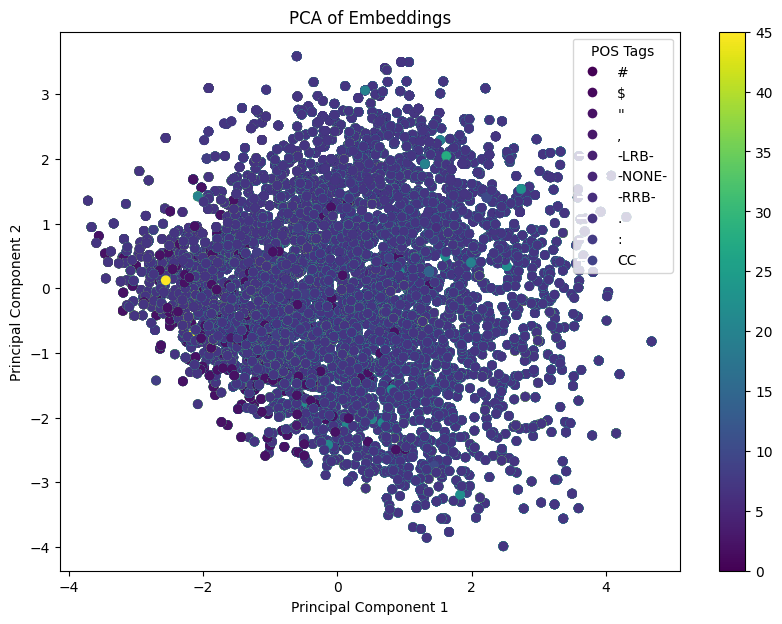

In [ ]:
# Embedding Generation Module

import os
import pickle
from transformers import GPT2Model, GPT2Tokenizer
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

class EmbeddingModule(PipelineModule):
    def __init__(self, name, model, tokenizer, cache_dir='cache'):
        super().__init__(name)
        self.model = model
        self.tokenizer = tokenizer
        self.cache_dir = cache_dir
        if not os.path.exists(cache_dir):
            os.makedirs(cache_dir)

    def process(self, data):
        # Generate embeddings using the specified model
        def get_embeddings(sentence):
            cache_path = os.path.join(self.cache_dir, f"{hash(sentence)}.pkl")
            if os.path.exists(cache_path):
                with open(cache_path, 'rb') as f:
                    embeddings = pickle.load(f)
            else:
                inputs = self.tokenizer(sentence, return_tensors='pt', truncation=True, padding=True).to(device)
                outputs = self.model(**inputs)
                embeddings = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().detach().numpy()
                with open(cache_path, 'wb') as f:
                    pickle.dump(embeddings, f)
            return embeddings

        data['embeddings'] = data['sentence'].apply(get_embeddings)
        return data

    def visualize_embeddings(self, data, n_components=2):
        # Visualize embeddings using PCA
        embeddings = np.vstack(data['embeddings'].values)
        pca = PCA(n_components=n_components)
        reduced_embeddings = pca.fit_transform(embeddings)
        
        # Convert string tags to numeric values for coloring
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        numeric_tags = le.fit_transform(data['tag'])
        
        plt.figure(figsize=(10, 7))
        scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], 
                            c=numeric_tags, cmap='viridis')
        
        # Create a legend showing what each color represents
        unique_tags = le.classes_
        handles = [plt.Line2D([0], [0], marker='o', color='w', 
                            markerfacecolor=plt.cm.viridis(i/len(unique_tags)), 
                            label=tag, markersize=8) 
                for i, tag in enumerate(unique_tags[:10])]  # Show only first 10 tags
        
        plt.legend(handles=handles, title='POS Tags', loc='upper right')
        plt.colorbar()
        plt.title('PCA of Embeddings')
        plt.xlabel('Principal Component 1')
        plt.ylabel('Principal Component 2')
        plt.show()

# Example usage of the EmbeddingModule
# embedding = EmbeddingModule('Embedding', GPT2Model, GPT2Tokenizer)
embedding = EmbeddingModule('Embedding', bert_model, bert_tokenizer)
embedded_data = embedding.process(treebank_data)

# Visualize the embeddings
embedding.visualize_embeddings(embedded_data)